In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kirtisinghdolphin","key":"ab8dc2e6339c6b71fb003c3efa0d3227"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                            BMW Global Automotive Sales                              55017  2026-02-22 18:18:38.170000           7839        151  1.0              
ssssws/chocolate-sales-dataset-2023-2024                            Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           1983         44  1.0              
thuandao/superstore-sales-analytics                                 SuperStore Sales Analytics                             2283450  2026-03-06 12:31:25.800000           2091         47

In [12]:
!rm -rf dataset

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace Garbage classification/Garbage classification/cardboard/cardboard1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Found 2503 images belonging to 3 classes.
Found 1216 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,051 (14.14 MB)

 Trainable params: 3,706,051 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 472ms/step - accuracy: 0.9449 - loss: 0.3555 - val_accuracy: 0.9416 - val_loss: 0.2003
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 480ms/step - accuracy: 0.9461 - loss: 0.1962 - val_accuracy: 0.9416 - val_loss: 0.1616
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 454ms/step - accuracy: 0.9461 - loss: 0.1988 - val_accuracy: 0.9416 - val_loss: 0.1563


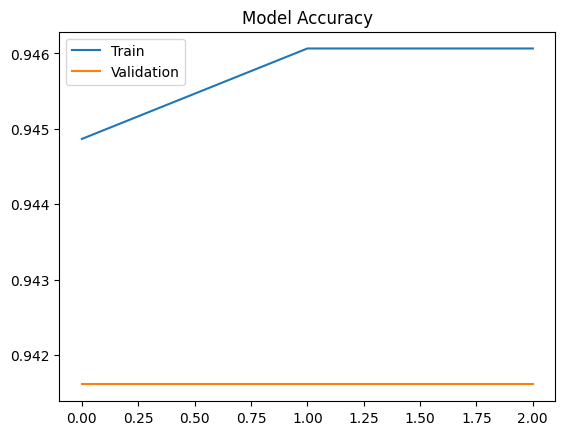

76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step


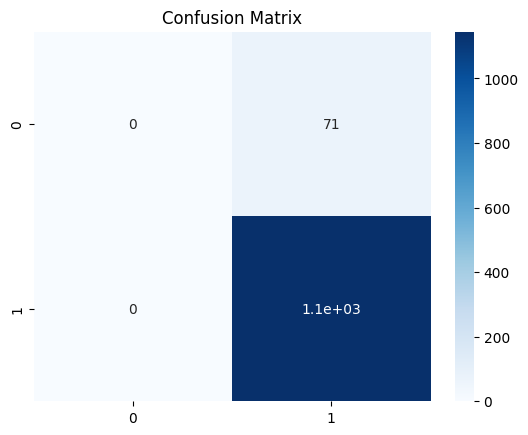

In [16]:
# ===============================
# 1. Install & Download Dataset
# ===============================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d asdasdasasdas/garbage-classification
!unzip -q garbage-classification.zip


# ===============================
# 2. Prepare Dataset
# ===============================
import os, shutil, random

base_dir = "dataset"
train_dir = os.path.join(base_dir,"train")
val_dir = os.path.join(base_dir,"validation")

classes = ["recyclable","organic","non_recyclable"]

for c in classes:
    os.makedirs(os.path.join(train_dir,c),exist_ok=True)
    os.makedirs(os.path.join(val_dir,c),exist_ok=True)

original_dataset = "Garbage classification/Garbage classification"

mapping = {
"paper":"recyclable",
"plastic":"recyclable",
"metal":"recyclable",
"glass":"recyclable",
"cardboard":"recyclable",
"trash":"non_recyclable"
}

for category in os.listdir(original_dataset):

    if category not in mapping:
        continue

    target_class = mapping[category]
    files = os.listdir(os.path.join(original_dataset,category))
    random.shuffle(files)

    split = int(0.8*len(files))

    train_files = files[:split]
    val_files = files[split:]

    for f in train_files:
        shutil.copy(os.path.join(original_dataset,category,f),
                    os.path.join(train_dir,target_class,f))

    for f in val_files:
        shutil.copy(os.path.join(original_dataset,category,f),
                    os.path.join(val_dir,target_class,f))


# ===============================
# 3. Data Generator (FAST)
# ===============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size=(128,128)   # 🔴 reduced from 224 → faster
batch_size=16        # 🔴 reduced from 32 → faster

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=15,
horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
"dataset/train",
target_size=img_size,
batch_size=batch_size,
class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
"dataset/validation",
target_size=img_size,
batch_size=batch_size,
class_mode="categorical",
shuffle=False
)


# ===============================
# 4. Simple CNN (FAST)
# ===============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(2,2),

Flatten(),

Dense(64,activation='relu'),
Dropout(0.3),

Dense(3,activation='softmax')
])

model.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)

model.summary()


# ===============================
# 5. Train Model (FAST)
# ===============================
history = model.fit(
train_generator,
epochs=3,      # 🔴 reduced epochs
validation_data=val_generator
)


# ===============================
# 6. Accuracy Graph
# ===============================
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()


# ===============================
# 7. Confusion Matrix
# ===============================
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

pred = model.predict(val_generator)

pred_classes = np.argmax(pred,axis=1)
true_classes = val_generator.classes

cm = confusion_matrix(true_classes,pred_classes)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Confusion Matrix")
plt.show()